In [ ]:
import marimo as mo

In [ ]:
from typing import TypedDict, List, Optional, Literal
import os
from dotenv import load_dotenv
import json

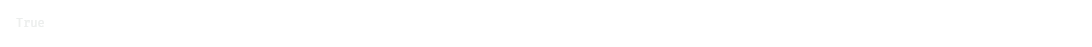

In [ ]:
load_dotenv(dotenv_path=r"F:\Files\Portfolio\.env")

In [ ]:
RESEARCHER_PROMPT = """
You are a research agent for a newsletter publication. Your job is to gather raw facts 
and findings on a topic using your search tool.

Topic: {topic}

Follow these steps:
1. Think about 3 different angles of this topic worth exploring
2. Search for each angle using the search tool — run at least 3 separate searches
3. If a search result is thin or unhelpful, search again with a different query
4. Keep searching until you have enough substance

Once you have gathered enough information, return your findings as a structured bullet list:

- Each bullet is one distinct fact, stat, quote, or insight
- Include the source title or URL next to each bullet in parentheses
- Group bullets under 3 headings: ## Key Facts, ## Stats & Numbers, ## Quotes & Insights
- Do NOT write prose, do NOT summarize, do NOT editorialize
- Only include what you actually found in your searches

Return ONLY the bullet list. No preamble, no conclusion, no markdown fences.
"""

WRITER_PROMPT = """
You are a newsletter writer. Your job is to turn raw research findings into an engaging 
newsletter section.

Topic: {topic}

Raw Research Findings:
{research_summary}

Previous Draft: {draft}
Fact-checker Feedback: {fact_check_notes}

Instructions:
- If Previous Draft is None, write a fresh newsletter section from the research findings
- If Previous Draft is not None, this is revision #{iteration} — fix exactly what the 
  fact-checker flagged and do not rewrite sections that were not flagged

Using ONLY the facts from the research findings, write a newsletter section that:
- Opens with a strong hook (1-2 sentences that grab attention)
- Covers the key insight or story in 3-4 short paragraphs
- Uses a conversational but informed tone (think: Morning Brew, not academic paper)
- Weaves in specific facts, stats, and quotes from the research naturally
- Ends with a 1-line takeaway or "why this matters"
- Is between 250-350 words

Do NOT add any facts, stats, or claims not present in the research findings above.
Return only the newsletter section text. No subject line, no headers, no JSON.
"""

FACT_CHECKER_PROMPT = """
You are a fact-checking agent for a newsletter publication. Your job is to verify a 
newsletter draft against the original research findings.

Topic: {topic}

Raw Research Findings (the ONLY source of truth):
{research_summary}

Newsletter Draft:
{draft}

Check the draft for:
1. Claims not present in the research findings
2. Exaggerated or distorted statistics
3. Quotes that are fabricated or misattributed
4. Missing critical context that changes the meaning of a claim

Rules:
- Do NOT penalize for tone, style, or writing quality
- Do NOT penalize for omitting facts — only flag things that are wrong or unsupported
- If a claim cannot be traced back to the research findings, flag it

Make a verdict:
- APPROVED: every claim in the draft is supported by the research findings
- NEEDS_REVISION: one or more claims are unsupported, exaggerated, or fabricated

Return your response in this exact JSON format:
{{
    "verdict": "APPROVED" or "NEEDS_REVISION",
    "notes": "If APPROVED write 'All claims verified.' If NEEDS_REVISION list each issue 
    as a numbered list with the exact claim and what is wrong with it."
}}

Return only JSON. No preamble, no markdown backticks.
"""


FORMATTER_PROMPT = """
You are a newsletter formatter. Your job is to take an approved newsletter draft and 
produce a clean, publish-ready newsletter section.

Topic: {topic}

Approved Draft:
{draft}

Format the draft as follows:
- Subject Line: compelling and under 60 characters
- Preview Text: 1 sentence teaser under 100 characters
- Body: the draft lightly cleaned — fix any awkward phrasing, ensure paragraph spacing 
  is clean, do NOT change facts or restructure content
- Sources: list only the titles and URLs provided above, do not add or remove any

Return your response in this exact JSON format:
{{
    "subject_line": "...",
    "preview_text": "...",
    "body": "...",
    "sources": [
        {{"title": "...", "url": "..."}}
    ]
}}

Return only JSON. No preamble, no markdown backticks.
"""

In [ ]:
class NewsletterState(TypedDict):
    # Input
    topic: str

    # Research
    search_queries: List[str]
    raw_sources: List[dict]        # [{"url": str, "title": str, "snippet": str}]
    research_summary: str

    # Writing
    draft: str
    iteration: int                 # tracks rewrite count

    # Fact-checking
    fact_check_verdict: Literal["APPROVED", "NEEDS_REVISION"]
    fact_check_notes: str          # what's wrong, what to fix

    # Final
    final_newsletter: Optional[str]
    status: Literal["researching", "writing", "fact_checking", "approved", "failed"]

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite',temperature=0.2, api_key=os.getenv("GEMINI_API_KEY"), max_tokens=4096)

In [ ]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(max_results=5, search_depth='advanced')

In [ ]:
from langchain.agents import create_agent

In [ ]:
def researcher(state: NewsletterState) -> NewsletterState:
    agent = create_agent(model=llm, tools=[search_tool], system_prompt=RESEARCHER_PROMPT)
    topic = state['topic']
    response = agent.invoke({"messages":topic})
    
    final_message = response["messages"][-1].content
    return {"research_summary":final_message, "status":"writing"}

In [ ]:
def writer(state: NewsletterState) -> NewsletterState:
    topic = state['topic']
    draft = state.get("draft", None)
    iteration = state.get('iteration',0)
    research_summary = state.get("research_summary",None)
    prompt = WRITER_PROMPT.format(
        topic=topic,
        research_summary=research_summary,
        draft=draft,
        fact_check_notes=state.get("fact_check_notes", "None"),
        iteration=iteration
    )
    response = llm.invoke(prompt).content[-1]['text']
    final_message = response.strip()
    return {"draft":final_message,
           "iteration":iteration + 1,
           "status":"fact_checking"}

In [ ]:
#conditional edge
def should_continue(state: NewsletterState) -> NewsletterState:
    verdict = state["fact_check_verdict"]
    if verdict == "APPROVED":
        return "approved"
    elif state['iteration'] > 3:
        return "failed"
    else:
        return "writer"


In [ ]:
def fact_checker(state: NewsletterState) -> NewsletterState:
    topic = state.get("topic")
    research_summary = state.get("research_summary",None)
    draft = state['draft']

    prompt = FACT_CHECKER_PROMPT.format(
        topic=topic,
        research_summary=research_summary,
        draft=draft
    )
    response = llm.invoke(prompt).content[-1]['text']
    raw = response.strip().removeprefix("```json").removesuffix("```").strip()
    parsed = json.loads(raw)

    return {"fact_check_verdict":parsed['verdict'],
           "fact_check_notes":parsed['notes'],
           "status":"APPROVED" if parsed['verdict'] == "APPROVED" else "fact checking"}

In [ ]:
def formatter(state: NewsletterState) -> NewsletterState:
    topic = state['topic']
    draft = state['draft']

    prompt = FORMATTER_PROMPT.format(
        topic=topic,
        draft=draft
    )
    response = llm.invoke(prompt).content[-1]['text']
    raw = response.strip().removeprefix("```json").removesuffix("```").strip()
    parsed = json.loads(raw)

    return {
        "final_newsletter": parsed,
        "status": "approved"
    }

In [ ]:
from langgraph.graph import StateGraph, MessagesState, START, END

In [ ]:
graph = StateGraph(NewsletterState)
graph.add_node(researcher)
graph.add_node(writer)
graph.add_node(fact_checker)
graph.add_node(formatter)


graph.add_edge(START, "researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer", "fact_checker")

graph.add_conditional_edges(
    "fact_checker",
    should_continue,
    {
        "writer": "writer",
        "approved":"formatter",
        "failed":END
    }
)

graph.add_edge("formatter", END)
graph = graph.compile()

In [ ]:
for chunk in graph.stream({"topic": "Hello world to Hello AI"}, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n{'='*40}")
        print(f"Node: {node_name}")
        print(f"{'='*40}")
        for key, value in node_output.items():
            print(f"{key}: {str(value)[:200]}...")  # truncate long outputs


Node: researcher
research_summary: [{'type': 'text', 'text': '## Key Facts\n\n- "Hello World" originated as a simple test program to verify that a computer language\'s compiler, runtime, and environment were functioning correctly (Code...
status: writing...

Node: writer
draft: For decades, the first step into the world of programming was a simple, two-word ritual: "Hello, World!" But as AI reshapes the developer landscape, that iconic rite of passage is evolving into someth...
iteration: 1...
status: fact_checking...

Node: fact_checker
fact_check_verdict: APPROVED...
fact_check_notes: All claims verified....
status: APPROVED...

Node: formatter
final_newsletter: {'subject_line': 'From Hello World to Hello AI: The New Developer Era', 'preview_text': "The iconic 'Hello, World!' ritual is evolving as AI transforms the developer landscape.", 'body': 'For decades,...
status: approved...


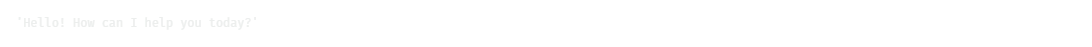

In [ ]:
llm.invoke("Hello").content[-1]['text']